In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving real_estate_dataset.csv to real_estate_dataset.csv


In [ ]:
df = pd.read_csv("real_estate_dataset.csv")

In [ ]:
df

,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere
...,...,...,...,...,...,...,...,...,...
282,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,Pune,2025-01-19,840 sqft,Residential apartment,3,10000000.0,Manjari Khurd
283,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Pune,2025-02-13,690 sqft,Residential apartment,2,6500000.0,Punawale
284,https://www.99acres.com/6-bhk-bedroom-independ...,6,Pune,2025-01-19,840 sqft,Independent House/Villa,6,13500000.0,Katraj
285,https://www.99acres.com/1-bhk-bedroom-apartmen...,1,Pune,2025-02-17,640 sqft,Residential apartment,1,3500000.0,Kirkatwadi


In [ ]:
df.columns
df.dtypes

,0
url,object
beds,int64
city,object
date,object
size,object
type,object
baths,int64
price,float64
neighborhood,object


In [ ]:
df.drop(columns=["date", "url"], inplace=True)

In [ ]:
print(df.head())
print(df.info())

   beds       city            size                     type  baths  \
0     0  Bangalore   799-1258 sqft  Residential land / Plot      0   
1     2  Bangalore       1085 sqft               2 BHK Flat      2   
2     3  Bangalore  1525-2150 sqft       3, 4 BHK Apartment      0   
3     2  Bangalore   658-1003 sqft       2, 3 BHK Apartment      0   
4     2  Bangalore  1179-1449 sqft       2, 3 BHK Apartment      0   

        price neighborhood  
0   2317000.0       Jigani  
1  12500000.0  Tumkur Road  
2  23200000.0   Whitefield  
3    889000.0  Soukya Road  
4   6483000.0      Kalkere  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   beds          287 non-null    int64  
 1   city          287 non-null    object 
 2   size          287 non-null    object 
 3   type          287 non-null    object 
 4   baths         287 non-null    int64  


In [ ]:
# Size is object(text) , which in not acceptable , it should be numeric.

import re

def extract_size(x):
    nums = re.findall(r'\d+', str(x))
    nums = list(map(int, nums))
    return sum(nums)/len(nums) if nums else None

In [ ]:
df["size"] = df["size"].apply(extract_size)

In [ ]:
df.isna().sum()

,0
beds,0
city,0
size,50
type,0
baths,0
price,0
neighborhood,0


In [ ]:
df["size"] = df["size"].fillna(df["size"].median())

In [ ]:
df["price"]

,price
0,2317000.0
1,12500000.0
2,23200000.0
3,889000.0
4,6483000.0
...,...
282,10000000.0
283,6500000.0
284,13500000.0
285,3500000.0


In [ ]:
# Define x and y feature variables

X = df.drop(columns=["price"])
y = df["price"]

In [ ]:
print(X.select_dtypes(include="object"))

          city                     type   neighborhood
0    Bangalore  Residential land / Plot         Jigani
1    Bangalore               2 BHK Flat    Tumkur Road
2    Bangalore       3, 4 BHK Apartment     Whitefield
3    Bangalore       2, 3 BHK Apartment    Soukya Road
4    Bangalore       2, 3 BHK Apartment        Kalkere
..         ...                      ...            ...
282       Pune    Residential apartment  Manjari Khurd
283       Pune    Residential apartment       Punawale
284       Pune  Independent House/Villa         Katraj
285       Pune    Residential apartment     Kirkatwadi
286       Pune    Residential apartment      Mahalunge

[287 rows x 3 columns]


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.select_dtypes(include="object"))

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[287 rows x 0 columns]


In [ ]:
print(X.shape)

(287, 298)


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()

In [ ]:
model.fit(x_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

print(r2_score(y_test, y_pred))

-3.923845177827455


# Since our Decision Tree is too weak and unstable, we will use Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
# Train again

model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict again

y_pred = model.predict(x_test)

In [ ]:
# Evaluate again

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.8347382245366328


In [ ]:
# Take the TOP 20 most frequent neighborhoods

df["neighborhood"].value_counts().head(20).index

Index(['Noida Greater Noida Expressway', 'Ramanayapeta', 'Madhurawada',
       'Sasikanth Nagar', 'Gajuwaka', 'Vennala', 'Sulur', 'Sector 49',
       'Tellapur', 'Mansarovar', 'Jagatpura', 'Dayal Bagh',
       'Sushant Golf City', 'Sargasan', 'Gomti Nagar Extension', 'Kovvada',
       'Chalikavattom', 'Randesan', 'Thuckalay', 'Gift City'],
      dtype='object', name='neighborhood')

In [ ]:
X = X.astype(float)

# Implement Grdient Descend

In [ ]:
# Initializes parameters: Starts with initial values for weight and bias, and sets the learning rate and number of iterations.

In [ ]:
w = np.zeros(X.shape[1])   # (298,)
b = 0
lr = 0.05
epochs = 200
losses = []
n = len(y)

In [ ]:
for i in range(epochs):
  # defining the linear eq line:
  y_pred = np.dot(X, w) + b
  # Compute Gradients
  # dw and db are slopes of the loss function
  dw = (-2/n)*np.dot(X.T, (y - y_pred))
  db = (-2/n)*np.sum(y - y_pred)
  # Update parameters
  w -= lr*dw
  b -= lr*db
  # Compute Loss
  loss = np.mean((y - y_pred)**2)
  # Print Progress
  if i%10 == 0:
    print(f"Epoch{i}, Loss: {loss}")

Epoch0, Loss: 2366592279023176.0
Epoch10, Loss: 9.965053245519153e+179
Epoch20, Loss: inf
Epoch30, Loss: inf
Epoch40, Loss: nan
Epoch50, Loss: nan
Epoch60, Loss: nan
Epoch70, Loss: nan
Epoch80, Loss: nan
Epoch90, Loss: nan
Epoch100, Loss: nan
Epoch110, Loss: nan
Epoch120, Loss: nan
Epoch130, Loss: nan
Epoch140, Loss: nan
Epoch150, Loss: nan
Epoch160, Loss: nan
Epoch170, Loss: nan
Epoch180, Loss: nan
Epoch190, Loss: nan


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
w = np.zeros(X.shape[1])   # (298,)
b = 0
lr = 0.01
epochs = 200
losses = []
n = len(y)

In [ ]:
for i in range(epochs):
  # defining the linear eq line:
  y_pred = np.dot(X, w) + b
  # Compute Gradients
  # dw and db are slopes of the loss function
  dw = (-2/n)*np.dot(X.T, (y - y_pred))
  db = (-2/n)*np.sum(y - y_pred)
  # Update parameters
  w -= lr*dw
  b -= lr*db
  # Compute Loss
  loss = np.mean((y - y_pred)**2)
  # Print Progress
  if i%10 == 0:
    print(f"Epoch{i}, Loss: {loss}")

Epoch0, Loss: 2366592279023176.0
Epoch10, Loss: 1515353173056537.0
Epoch20, Loss: 1002335601978115.8
Epoch30, Loss: 679329047515886.0
Epoch40, Loss: 470822989311994.56
Epoch50, Loss: 334202276747693.7
Epoch60, Loss: 243764969209705.1
Epoch70, Loss: 183387741479616.62
Epoch80, Loss: 142727859351484.6
Epoch90, Loss: 115066643408551.67
Epoch100, Loss: 96007737691668.58
Epoch110, Loss: 82661636301112.06
Epoch120, Loss: 73123678133639.48
Epoch130, Loss: 66135705428521.66
Epoch140, Loss: 60865150461598.95
Epoch150, Loss: 56760147143245.42
Epoch160, Loss: 53454231076968.65
Epoch170, Loss: 50703534012735.87
Epoch180, Loss: 48345334963144.77
Epoch190, Loss: 46270676435015.6


In [ ]:
# applied standardization (Z-score normalization)

y = (y - y.mean()) / y.std()

# After this step the output came below. The output changed significantly.

# Gradient Descent works best when both X and y are on similar scale

# Batch GD is too slow , so We will try Mini Batch GD

In [ ]:
# Step 1: Choose Batch Size

batch_size = 32 # With 287 samples: ~9 batches per epoch
epochs = 100
lr = 0.01

w = np.zeros(X.shape[1])
b = 0

n = len(X)

In [ ]:
for epoch in range(epochs):

    # Shuffle data
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Predictions
        y_pred = np.dot(X_batch, w) + b

        # Gradients
        m = len(X_batch)
        dw = (-2/m) * np.dot(X_batch.T, (y_batch - y_pred))
        db = (-2/m) * np.sum(y_batch - y_pred)

        # Update
        w -= lr * dw
        b -= lr * db

    # Compute loss on full dataset (for monitoring)
    y_full_pred = np.dot(X, w) + b
    loss = np.mean((y - y_full_pred)**2)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.6390013294192467
Epoch 10, Loss: 0.04039010009424905
Epoch 20, Loss: 0.022138862095643915
Epoch 30, Loss: 0.015884332416156412
Epoch 40, Loss: 0.011881134173397197
Epoch 50, Loss: 0.00921942992852179
Epoch 60, Loss: 0.0074259605053735925
Epoch 70, Loss: 0.006212383739016694
Epoch 80, Loss: 0.005383485961887886
Epoch 90, Loss: 0.004812393071618186


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = np.dot(X_test, w) + b

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.975698212767388
MAE: 0.029433124496008115


In [ ]:
# Convert Predictions Back

y_mean = y.mean()
y_std = y.std()

y = (y - y_mean) / y_std

y_pred_actual = y_pred * y_std + y_mean

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Sklearn R2:", r2_score(y_test, model.predict(X_test)))

Sklearn R2: -18.73883924257039


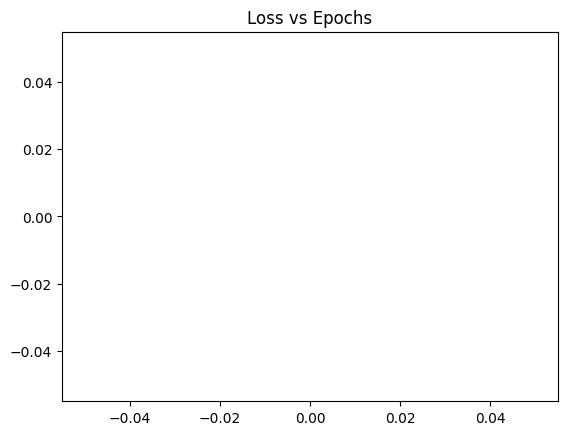

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Loss vs Epochs")
plt.show()

In [ ]:
losses = []

for epoch in range(epochs):

    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        y_pred = np.dot(X_batch, w) + b

        m = len(X_batch)
        dw = (-2/m) * np.dot(X_batch.T, (y_batch - y_pred))
        db = (-2/m) * np.sum(y_batch - y_pred)

        w -= lr * dw
        b -= lr * db

    # full loss
    y_full_pred = np.dot(X, w) + b
    loss = np.mean((y - y_full_pred)**2)

    losses.append(loss)   # ✅ THIS WAS MISSING

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.004412313785389606
Epoch 10, Loss: 0.0041279810719179995
Epoch 20, Loss: 0.00392144848286179
Epoch 30, Loss: 0.0037715361719635088
Epoch 40, Loss: 0.0036564046714603637
Epoch 50, Loss: 0.0035693418761714567
Epoch 60, Loss: 0.0035021179291527273
Epoch 70, Loss: 0.003444878634846895
Epoch 80, Loss: 0.003401003507091382
Epoch 90, Loss: 0.0033637606030782826


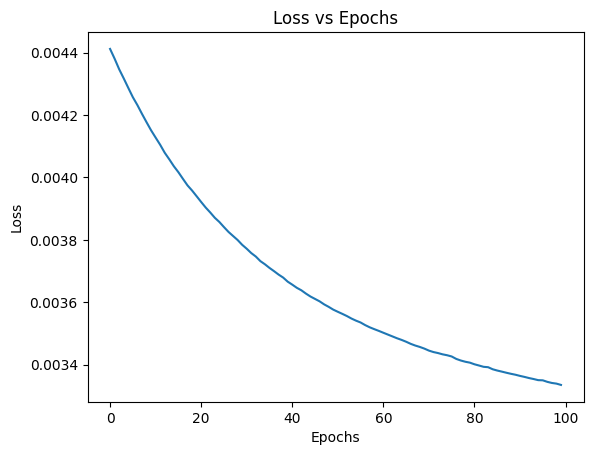

In [ ]:
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()